In [32]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix


In [33]:
df = pd.read_csv("../Data/processed/ONE_SENSOR_TRAFIC_DATA_ONLY.csv")

In [34]:
df = df.sort_values("timestamp").reset_index(drop=True)

split_idx = int(len(df) * 0.7)

train_df = df.iloc[:split_idx].copy()
test_df = df.iloc[split_idx:].copy()

print("Train:", train_df["timestamp"].min(), "→", train_df["timestamp"].max())
print("Test:", test_df["timestamp"].min(), "→", test_df["timestamp"].max())
print(train_df.shape, test_df.shape)

Train: 2024-01-01 01:30:00 → 2024-01-22 15:45:00
Test: 2024-01-22 15:50:00 → 2024-01-31 21:55:00
(6220, 57) (2666, 57)


In [35]:
df.columns

Index(['flow', 'occupancy', 'speed', 'timestamp', 'sensor_index', 'sensor_id',
       'date', 'is_congested', 'congestion_30min', 'congestion_60min',
       'congestion_90min', 'congestion_120min', 'hour', 'minute',
       'day_of_week', 'day', 'is_weekend', 'hour_sin', 'hour_cos', 'dow_sin',
       'dow_cos', 'speed_lag_5m', 'flow_lag_5m', 'occupancy_lag_5m',
       'speed_lag_15m', 'flow_lag_15m', 'occupancy_lag_15m', 'speed_lag_30m',
       'flow_lag_30m', 'occupancy_lag_30m', 'speed_lag_60m', 'flow_lag_60m',
       'occupancy_lag_60m', 'speed_lag_90m', 'flow_lag_90m',
       'occupancy_lag_90m', 'speed_roll_mean_15m', 'speed_roll_std_15m',
       'flow_roll_mean_15m', 'occupancy_roll_mean_15m', 'speed_roll_mean_30m',
       'speed_roll_std_30m', 'flow_roll_mean_30m', 'occupancy_roll_mean_30m',
       'speed_roll_mean_60m', 'speed_roll_std_60m', 'flow_roll_mean_60m',
       'occupancy_roll_mean_60m', 'speed_roll_mean_90m', 'speed_roll_std_90m',
       'flow_roll_mean_90m', 'occupanc

In [36]:
target_cols = [
    "congestion_30min",
    "congestion_60min",
    "congestion_90min",
    "congestion_120min"
]

feature_cols = ['flow', 'occupancy', 'speed', 'is_congested', 'hour', 'minute',
       'day_of_week', 'day', 'is_weekend', 'hour_sin', 'hour_cos', 'dow_sin',
       'dow_cos', 'speed_lag_5m', 'flow_lag_5m', 'occupancy_lag_5m',
       'speed_lag_15m', 'flow_lag_15m', 'occupancy_lag_15m', 'speed_lag_30m',
       'flow_lag_30m', 'occupancy_lag_30m', 'speed_lag_60m', 'flow_lag_60m',
       'occupancy_lag_60m', 'speed_lag_90m', 'flow_lag_90m',
       'occupancy_lag_90m', 'speed_roll_mean_15m', 'speed_roll_std_15m',
       'flow_roll_mean_15m', 'occupancy_roll_mean_15m', 'speed_roll_mean_30m',
       'speed_roll_std_30m', 'flow_roll_mean_30m', 'occupancy_roll_mean_30m',
       'speed_roll_mean_60m', 'speed_roll_std_60m', 'flow_roll_mean_60m',
       'occupancy_roll_mean_60m', 'speed_roll_mean_90m', 'speed_roll_std_90m',
       'flow_roll_mean_90m', 'occupancy_roll_mean_90m', 'speed_diff_5m',
       'speed_diff_15m', 'speed_diff_30m', 'occupancy_diff_5m',
       'occupancy_diff_15m']

In [37]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score

baseline_results = []

for target in target_cols:
    y_true = test_df[target]
    
    # Baseline: asumo que el futuro será igual al estado actual
    y_pred = test_df["is_congested"]
    
    baseline_results.append({
        "target": target,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "positive_rate_true": y_true.mean(),
        "positive_rate_pred": y_pred.mean()
    })

baseline_results_df = pd.DataFrame(baseline_results)

baseline_results_df

,target,accuracy,precision,recall,f1,positive_rate_true,positive_rate_pred
0,congestion_30min,0.900600,0.882716,0.883495,0.883105,0.424981,0.425356
1,congestion_60min,0.858590,0.833333,0.834069,0.833701,0.424981,0.425356
2,congestion_90min,0.821080,0.788360,0.790451,0.789404,0.424231,0.425356
3,congestion_120min,0.782071,0.742504,0.744474,0.743488,0.424231,0.425356


In [38]:
target = "congestion_30min"

y_true = test_df[target]
y_pred = test_df["is_congested"]

cm = confusion_matrix(y_true, y_pred)

cm

array([[1400,  133],
       [ 132, 1001]])

In [39]:
early_test_df = test_df[test_df["is_congested"] == 0].copy()

early_warning_results = []

for target in target_cols:
    y_true = early_test_df[target]
    
    # Persistence baseline en casos no congestionados ahora siempre predice 0
    y_pred = early_test_df["is_congested"]
    
    early_warning_results.append({
        "target": target,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "positive_rate_true": y_true.mean(),
        "n_rows": len(early_test_df)
    })

early_warning_results_df = pd.DataFrame(early_warning_results)

early_warning_results_df

,target,accuracy,precision,recall,f1,positive_rate_true,n_rows
0,congestion_30min,0.913838,0.0,0.0,0.0,0.086162,1532
1,congestion_60min,0.877285,0.0,0.0,0.0,0.122715,1532
2,congestion_90min,0.845300,0.0,0.0,0.0,0.154700,1532
3,congestion_120min,0.811358,0.0,0.0,0.0,0.188642,1532


El baseline de persistencia no sirve para detectar congestión antes de que ocurra. Si el tráfico todavía no está congestionado, siempre predice que seguirá normal. Por eso tiene recall 0 en los casos de early warning.

In [40]:
train_df[feature_cols].isna().sum()[train_df[feature_cols].isna().sum() > 0]

Series([], dtype: int64)

In [41]:
train_df["occupancy_lag_90m"]

0       0.0125
1       0.0068
2       0.0082
3       0.0196
4       0.0303
         ...  
6215    0.0931
6216    0.0924
6217    0.1220
6218    0.1907
6219    0.1646
Name: occupancy_lag_90m, Length: 6220, dtype: float64

In [42]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

logreg_models = {}
logreg_results = []

for target in target_cols:
    X_train = train_df[feature_cols]
    y_train = train_df[target]

    X_test = test_df[feature_cols]
    y_test = test_df[target]

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        ))
    ])

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    logreg_models[target] = model

    logreg_results.append({
        "target": target,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_proba),
        "positive_rate_true": y_test.mean(),
        "positive_rate_pred": y_pred.mean()
    })

logreg_results_df = pd.DataFrame(logreg_results)

logreg_results_df

,target,accuracy,precision,recall,f1,roc_auc,positive_rate_true,positive_rate_pred
0,congestion_30min,0.917104,0.881271,0.930274,0.905109,0.971201,0.424981,0.448612
1,congestion_60min,0.903976,0.868797,0.911739,0.889750,0.957759,0.424981,0.445986
2,congestion_90min,0.904726,0.871925,0.908930,0.890043,0.950441,0.424231,0.442236
3,congestion_120min,0.897599,0.874346,0.885942,0.880105,0.948122,0.424231,0.429857


In [43]:
early_test_df = test_df[test_df["is_congested"] == 0].copy()

logreg_early_results = []

for target in target_cols:
    model = logreg_models[target]

    X_early = early_test_df[feature_cols]
    y_early = early_test_df[target]

    y_pred = model.predict(X_early)
    y_proba = model.predict_proba(X_early)[:, 1]

    logreg_early_results.append({
        "target": target,
        "accuracy": accuracy_score(y_early, y_pred),
        "precision": precision_score(y_early, y_pred, zero_division=0),
        "recall": recall_score(y_early, y_pred, zero_division=0),
        "f1": f1_score(y_early, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_early, y_proba),
        "positive_rate_true": y_early.mean(),
        "positive_rate_pred": y_pred.mean(),
        "n_rows": len(early_test_df)
    })

logreg_early_results_df = pd.DataFrame(logreg_early_results)

logreg_early_results_df

,target,accuracy,precision,recall,f1,roc_auc,positive_rate_true,positive_rate_pred,n_rows
0,congestion_30min,0.941253,0.664062,0.643939,0.653846,0.963301,0.086162,0.083551,1532
1,congestion_60min,0.943864,0.777174,0.760638,0.768817,0.976527,0.122715,0.120104,1532
2,congestion_90min,0.954308,0.881279,0.814346,0.846491,0.977678,0.154700,0.142950,1532
3,congestion_120min,0.954308,0.958159,0.792388,0.867424,0.983503,0.188642,0.156005,1532


In [44]:
comparison = baseline_results_df.merge(
    logreg_results_df,
    on="target",
    suffixes=("_baseline", "_logreg")
)

comparison[
    [
        "target",
        "accuracy_baseline",
        "accuracy_logreg",
        "precision_baseline",
        "precision_logreg",
        "recall_baseline",
        "recall_logreg",
        "f1_baseline",
        "f1_logreg",
        "roc_auc"
    ]
]

,target,accuracy_baseline,accuracy_logreg,precision_baseline,precision_logreg,recall_baseline,recall_logreg,f1_baseline,f1_logreg,roc_auc
0,congestion_30min,0.900600,0.917104,0.882716,0.881271,0.883495,0.930274,0.883105,0.905109,0.971201
1,congestion_60min,0.858590,0.903976,0.833333,0.868797,0.834069,0.911739,0.833701,0.889750,0.957759
2,congestion_90min,0.821080,0.904726,0.788360,0.871925,0.790451,0.908930,0.789404,0.890043,0.950441
3,congestion_120min,0.782071,0.897599,0.742504,0.874346,0.744474,0.885942,0.743488,0.880105,0.948122


In [45]:
early_test_df = test_df[test_df["is_congested"] == 0].copy()

logreg_early_results = []

for target in target_cols:
    model = logreg_models[target]

    X_early = early_test_df[feature_cols]
    y_early = early_test_df[target]

    y_pred = model.predict(X_early)
    y_proba = model.predict_proba(X_early)[:, 1]

    logreg_early_results.append({
        "target": target,
        "accuracy": accuracy_score(y_early, y_pred),
        "precision": precision_score(y_early, y_pred, zero_division=0),
        "recall": recall_score(y_early, y_pred, zero_division=0),
        "f1": f1_score(y_early, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_early, y_proba),
        "positive_rate_true": y_early.mean(),
        "positive_rate_pred": y_pred.mean(),
        "n_rows": len(early_test_df)
    })

logreg_early_results_df = pd.DataFrame(logreg_early_results)

logreg_early_results_df

,target,accuracy,precision,recall,f1,roc_auc,positive_rate_true,positive_rate_pred,n_rows
0,congestion_30min,0.941253,0.664062,0.643939,0.653846,0.963301,0.086162,0.083551,1532
1,congestion_60min,0.943864,0.777174,0.760638,0.768817,0.976527,0.122715,0.120104,1532
2,congestion_90min,0.954308,0.881279,0.814346,0.846491,0.977678,0.154700,0.142950,1532
3,congestion_120min,0.954308,0.958159,0.792388,0.867424,0.983503,0.188642,0.156005,1532


In [46]:
threshold_results = []

early_test_df = test_df[test_df["is_congested"] == 0].copy()

thresholds = np.arange(0.10, 1, 0.05)

for target in target_cols:
    model = logreg_models[target]

    X_early = early_test_df[feature_cols]
    y_true = early_test_df[target]
    y_proba = model.predict_proba(X_early)[:, 1]

    for threshold in thresholds:
        y_pred = (y_proba >= threshold).astype(int)

        threshold_results.append({
            "target": target,
            "threshold": threshold,
            "accuracy": accuracy_score(y_true, y_pred),
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "recall": recall_score(y_true, y_pred, zero_division=0),
            "f1": f1_score(y_true, y_pred, zero_division=0),
            "positive_rate_pred": y_pred.mean(),
            "positive_rate_true": y_true.mean()
        })

threshold_results_df = pd.DataFrame(threshold_results)

threshold_results_df.head()

,target,threshold,accuracy,precision,recall,f1,positive_rate_pred,positive_rate_true
0,congestion_30min,0.10,0.898825,0.456604,0.916667,0.609572,0.172977,0.086162
1,congestion_30min,0.15,0.913185,0.497738,0.833333,0.623229,0.144256,0.086162
2,congestion_30min,0.20,0.922977,0.535000,0.810606,0.644578,0.130548,0.086162
3,congestion_30min,0.25,0.930157,0.569832,0.772727,0.655949,0.116841,0.086162
4,congestion_30min,0.30,0.934073,0.593939,0.742424,0.659933,0.107702,0.086162


In [47]:
best_f1_thresholds = (
    threshold_results_df
    .sort_values(["target", "f1"], ascending=[True, False])
    .groupby("target")
    .head(1)
)

best_f1_thresholds

,target,threshold,accuracy,precision,recall,f1,positive_rate_pred,positive_rate_true
58,congestion_120min,0.30,0.954308,0.895307,0.858131,0.876325,0.180809,0.188642
4,congestion_30min,0.30,0.934073,0.593939,0.742424,0.659933,0.107702,0.086162
24,congestion_60min,0.40,0.944517,0.746411,0.829787,0.785894,0.136423,0.122715
43,congestion_90min,0.45,0.953655,0.867257,0.827004,0.846652,0.147520,0.154700


In [48]:
high_recall_thresholds = (
    threshold_results_df[threshold_results_df["recall"] >= 0.85]
    .sort_values(["target", "precision"], ascending=[True, False])
    .groupby("target")
    .head(1)
)

high_recall_thresholds

,target,threshold,accuracy,precision,recall,f1,positive_rate_pred,positive_rate_true
58,congestion_120min,0.30,0.954308,0.895307,0.858131,0.876325,0.180809,0.188642
0,congestion_30min,0.10,0.898825,0.456604,0.916667,0.609572,0.172977,0.086162
23,congestion_60min,0.35,0.941906,0.723982,0.851064,0.782396,0.144256,0.122715
40,congestion_90min,0.30,0.943864,0.791506,0.864979,0.826613,0.169060,0.154700


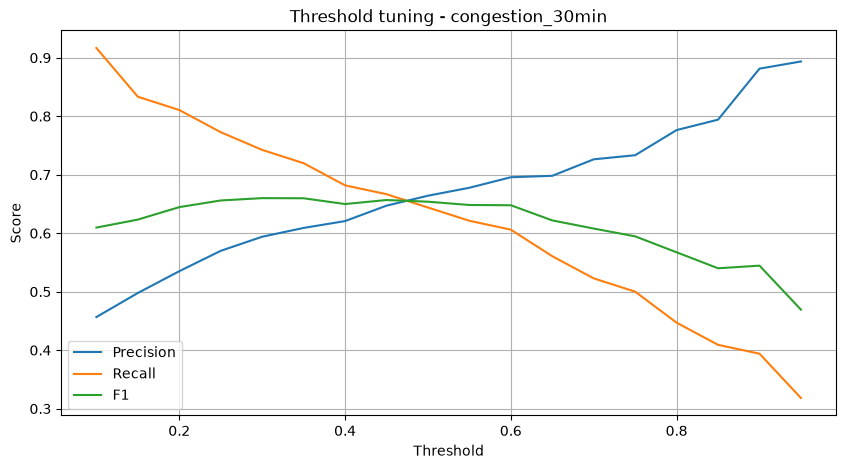

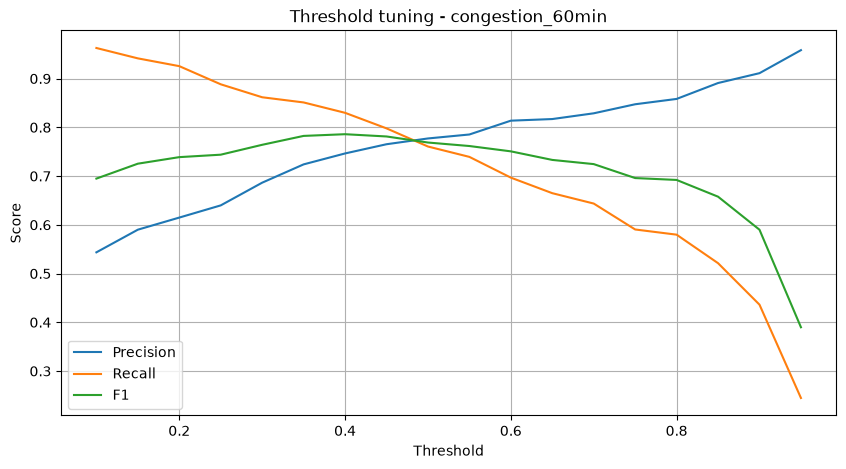

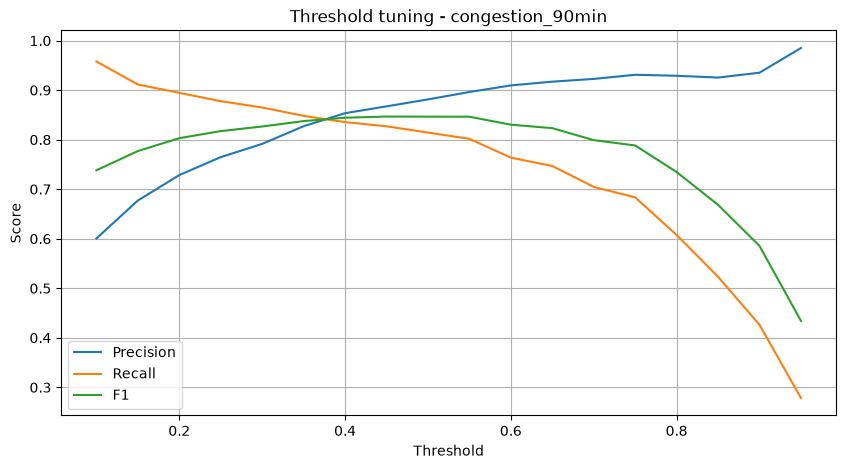

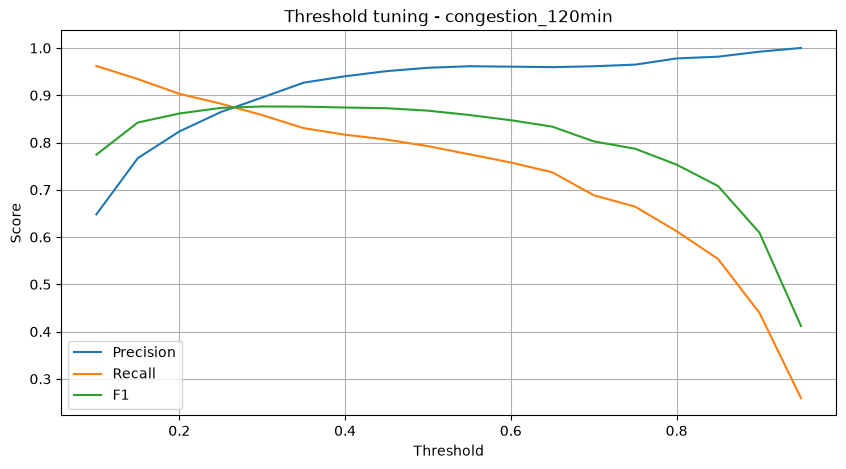

In [49]:
import matplotlib.pyplot as plt

for target in target_cols:
    temp = threshold_results_df[threshold_results_df["target"] == target]

    plt.figure(figsize=(10, 5))
    plt.plot(temp["threshold"], temp["precision"], label="Precision")
    plt.plot(temp["threshold"], temp["recall"], label="Recall")
    plt.plot(temp["threshold"], temp["f1"], label="F1")

    plt.title(f"Threshold tuning - {target}")
    plt.xlabel("Threshold")
    plt.ylabel("Score")
    plt.legend()
    plt.grid(True)
    plt.show()

In [55]:
OPERATIONAL_THRESHOLD = 0.4

tuned_results = []

for target in target_cols:
    model = logreg_models[target]

    X_test = test_df[feature_cols]
    y_true = test_df[target]

    y_proba = model.predict_proba(X_test)[:, 1]
    y_pred = (y_proba >= OPERATIONAL_THRESHOLD).astype(int)

    tuned_results.append({
        "target": target,
        "threshold": OPERATIONAL_THRESHOLD,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "positive_rate_true": y_true.mean(),
        "positive_rate_pred": y_pred.mean()
    })

tuned_results_df = pd.DataFrame(tuned_results)

tuned_results_df

,target,threshold,accuracy,precision,recall,f1,positive_rate_true,positive_rate_pred
0,congestion_30min,0.4,0.916354,0.866935,0.948808,0.906026,0.424981,0.465116
1,congestion_60min,0.4,0.900975,0.847878,0.934687,0.889169,0.424981,0.468492
2,congestion_90min,0.4,0.900600,0.854918,0.922193,0.887282,0.424231,0.457614
3,congestion_120min,0.4,0.899850,0.863636,0.907162,0.884864,0.424231,0.445611


In [61]:
early_test_df = test_df[test_df["is_congested"] == 0].copy()

tuned_early_results = []

for target in target_cols:
    model = logreg_models[target]

    X_early = early_test_df[feature_cols]
    y_true = early_test_df[target]

    y_proba = model.predict_proba(X_early)[:, 1]
    y_pred = (y_proba >= OPERATIONAL_THRESHOLD).astype(int)

    tuned_early_results.append({
        "target": target,
        "threshold": OPERATIONAL_THRESHOLD,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "positive_rate_true": y_true.mean(),
        "positive_rate_pred": y_pred.mean(),
        "n_rows": len(early_test_df)
    })

tuned_early_results_df = pd.DataFrame(tuned_early_results)

tuned_early_results_df

,target,threshold,accuracy,precision,recall,f1,positive_rate_true,positive_rate_pred,n_rows
0,congestion_30min,0.4,0.936684,0.620690,0.681818,0.649819,0.086162,0.094648,1532
1,congestion_60min,0.4,0.944517,0.746411,0.829787,0.785894,0.122715,0.136423,1532
2,congestion_90min,0.4,0.952350,0.853448,0.835443,0.844350,0.154700,0.151436,1532
3,congestion_120min,0.4,0.955614,0.940239,0.816609,0.874074,0.188642,0.163838,1532


In [68]:
df_alerts = test_df.copy()

for target in target_cols:
    horizon = target.replace("congestion_", "")

    model = logreg_models[target]

    proba_col = f"proba_{horizon}"
    alert_col = f"alert_{horizon}"

    df_alerts[proba_col] = model.predict_proba(
        df_alerts[feature_cols]
    )[:, 1]

    df_alerts[alert_col] = (
        df_alerts[proba_col] >= OPERATIONAL_THRESHOLD
    ).astype(int)

df_alerts.head()

,flow,occupancy,speed,timestamp,sensor_index,sensor_id,date,is_congested,congestion_30min,congestion_60min,...,occupancy_diff_5m,occupancy_diff_15m,proba_30min,alert_30min,proba_60min,alert_60min,proba_90min,alert_90min,proba_120min,alert_120min
6220,175.0,0.0771,26.8,2024-01-22 15:50:00,14698,819086,2024-01-22,1,0,1,...,-0.1171,-0.1923,0.067260,0,0.215314,0,0.162476,0,0.102422,0
6221,234.0,0.1069,32.5,2024-01-22 15:55:00,14698,819086,2024-01-22,0,0,1,...,0.0298,-0.2093,0.189895,0,0.496646,1,0.325629,0,0.217626,0
6222,194.0,0.0804,36.5,2024-01-22 16:00:00,14698,819086,2024-01-22,0,0,0,...,-0.0265,-0.1138,0.243378,0,0.308704,0,0.263458,0,0.060490,0
6223,219.0,0.0953,38.8,2024-01-22 16:05:00,14698,819086,2024-01-22,0,0,0,...,0.0149,0.0182,0.339875,0,0.362565,0,0.201695,0,0.046006,0
6224,231.0,0.0826,43.0,2024-01-22 16:10:00,14698,819086,2024-01-22,0,0,0,...,-0.0127,-0.0243,0.194773,0,0.289756,0,0.162082,0,0.063515,0
